# 📈 04 — Visualization & Visual EDA

**Objective:** Create comprehensive visualizations — histograms, trend lines, COVID impact charts, correlation heatmaps, box plots, pie charts, and scatter plots.

## 4.1 Pollutant Distribution — Histograms

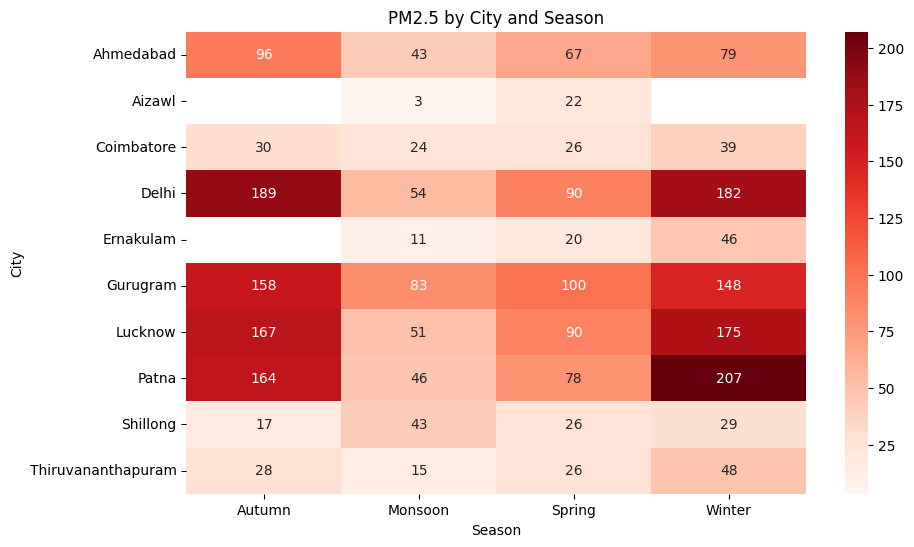

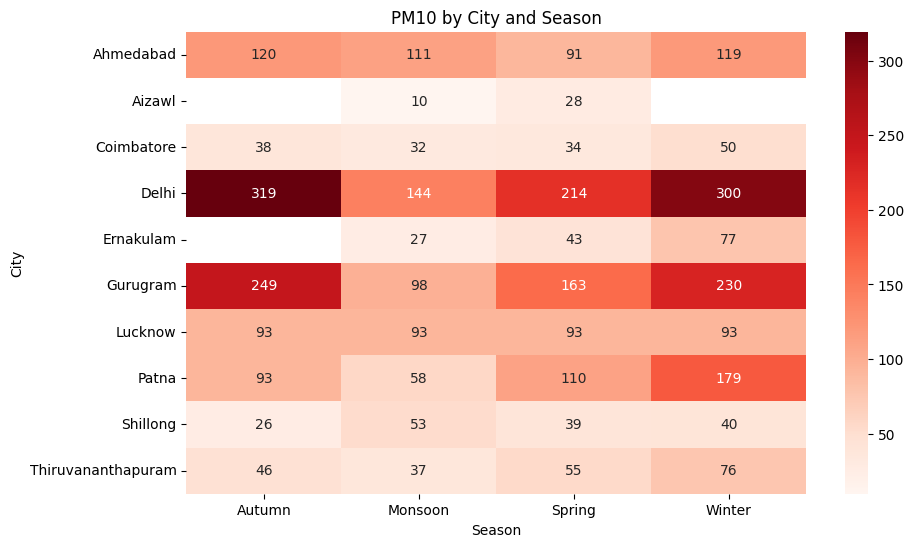

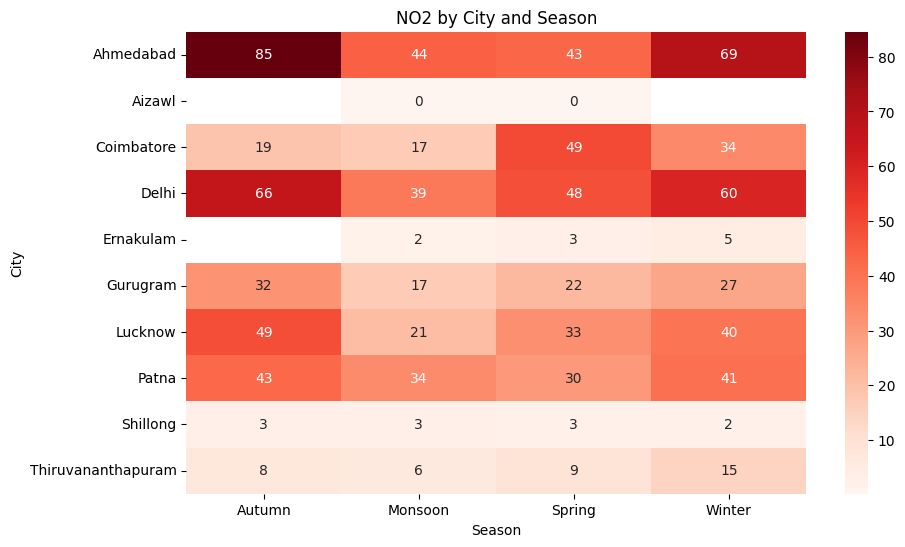

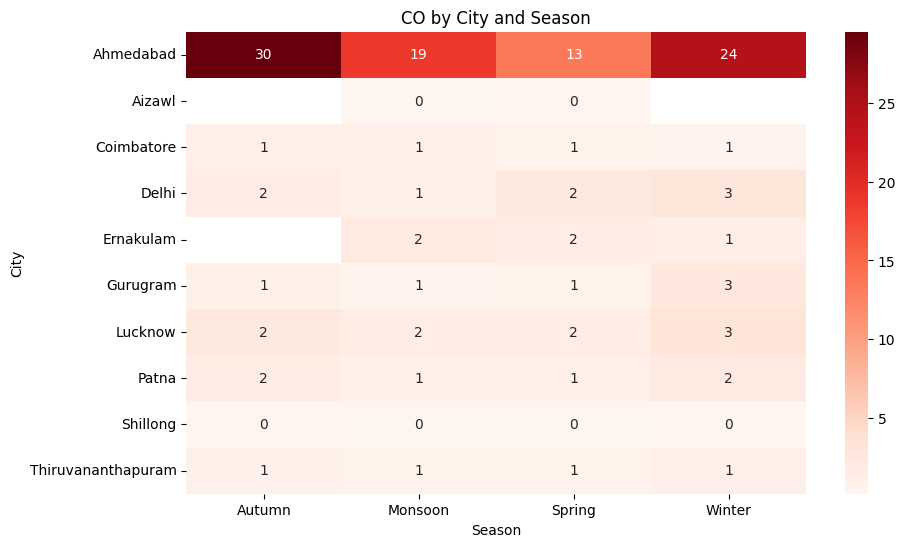

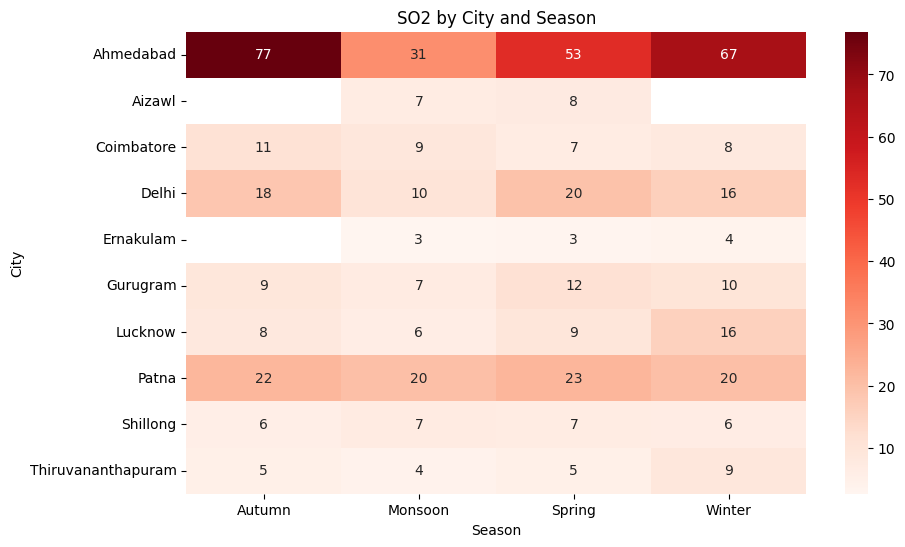

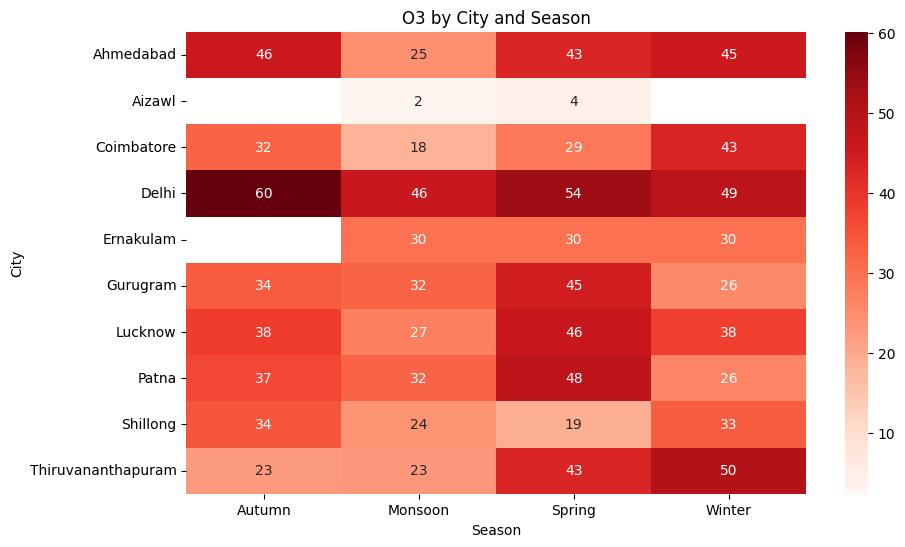

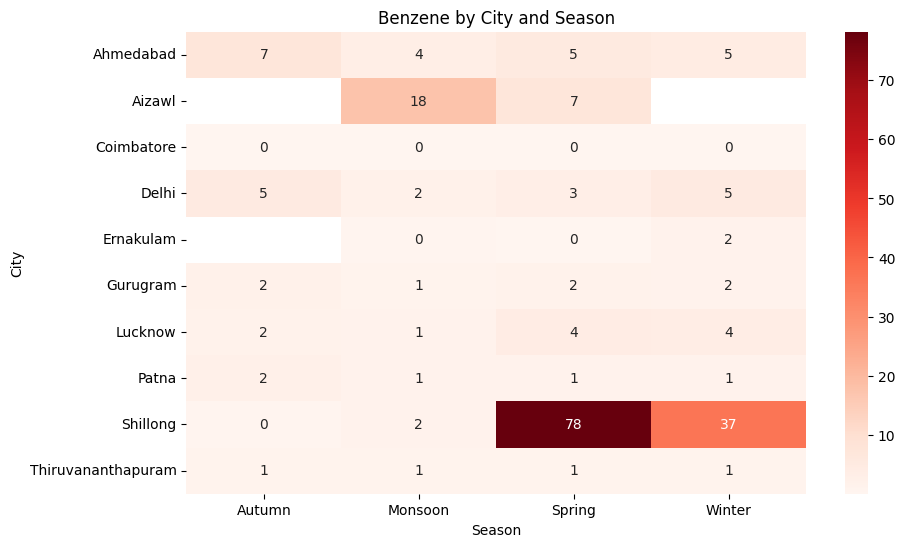

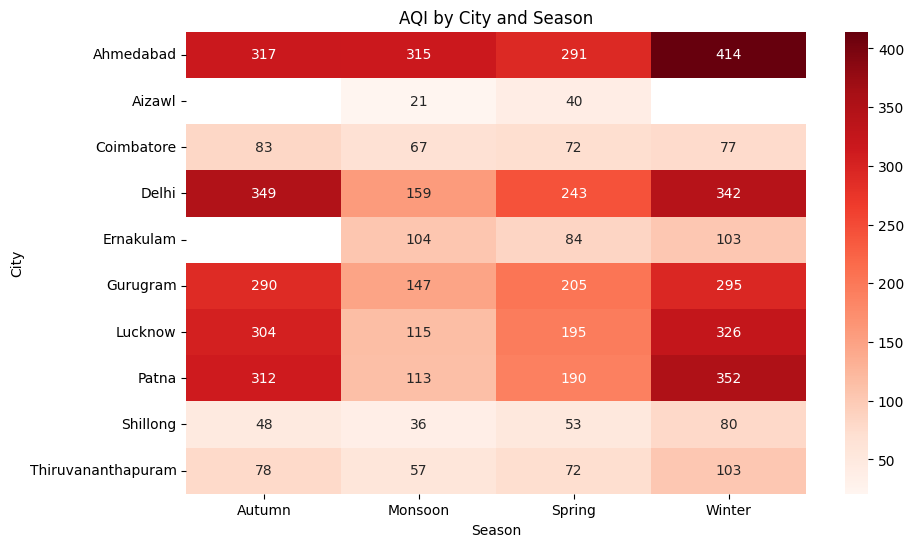

In [38]:
import seaborn as sns 
import matplotlib.pyplot as plt

pollutants = ['PM2.5', 'PM10', 'NO2', 'CO', 'SO2', 'O3', 'Benzene', 'AQI']

for pol in pollutants:
    pivot = trend_filtered.pivot_table(
    index = 'City',
    columns = 'Season',
    values = pol
    )
    plt.figure(figsize=(10,6))
    sns.heatmap(pivot,annot=True,fmt='.0f',cmap='Reds')
    plt.title(f'{pol} by City and Season')
    plt.show()

## 4.2 AQI Trend by City (2015–2020)

In [39]:
line_data = df[df['City'].isin(top+bottom)].groupby(['City','Year'])['AQI'].mean().reset_index()

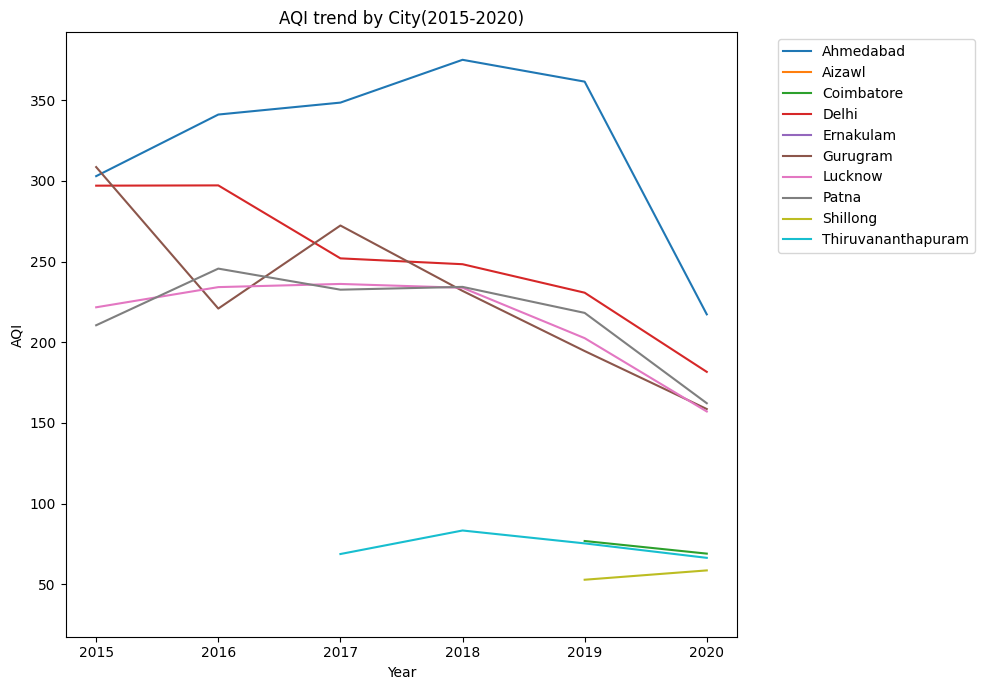

In [40]:
plt.figure(figsize=(10,7))
sns.lineplot(
    data=line_data,
    x='Year',
    y='AQI',
    hue='City'
)
plt.title('AQI trend by City(2015-2020)')
plt.legend(bbox_to_anchor=(1.05,1), loc='upper left')
plt.tight_layout()
plt.show()

## 4.3 COVID Impact — Delhi AQI (2019 vs 2020)

In [41]:
covid_data = df[
              (df['City'] == 'Delhi') &
              (df['Year'].isin([2019,2020]))].groupby(['Month','Year'])['AQI'].mean().reset_index()


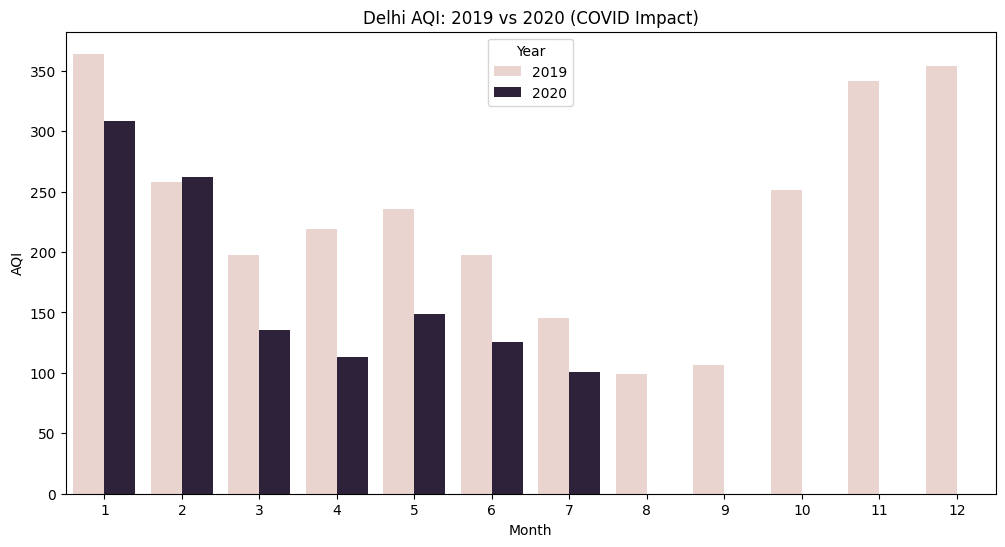

In [42]:
plt.figure(figsize = (12,6))
sns.barplot(
    data = covid_data,
    x = 'Month',
    y = 'AQI',
    hue = 'Year'
)
plt.title('Delhi AQI: 2019 vs 2020 (COVID Impact)')
plt.show()

## 4.4 Correlation Heatmap

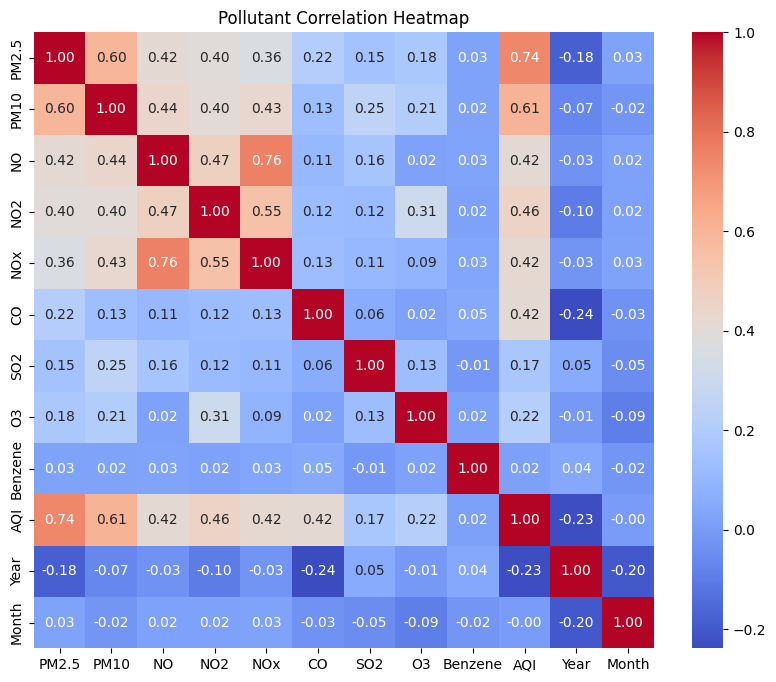

In [43]:
plt.figure(figsize=(10,8))
sns.heatmap(df.select_dtypes(include='number').corr(),annot=True,fmt='.2f',cmap='coolwarm')              #df[['PM2.5','PM10','NO2','CO','SO2','O3','Benzene','AQI']]
plt.title('Pollutant Correlation Heatmap')
plt.show()

## 4.5 Box Plots — Pollutant Distribution by City

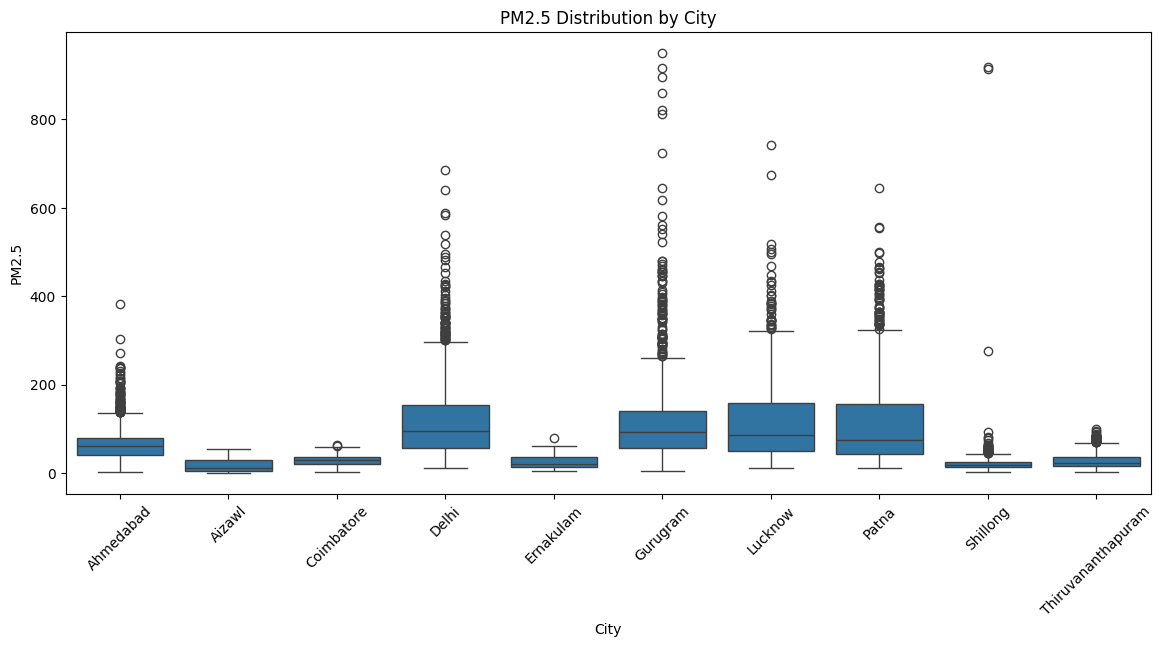

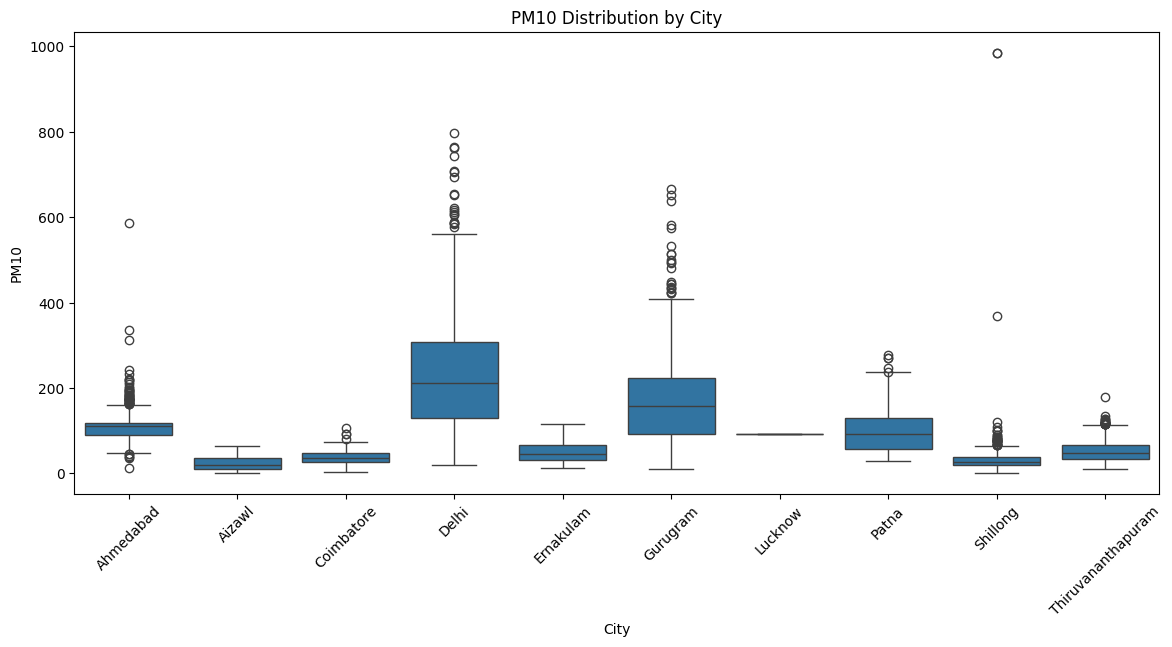

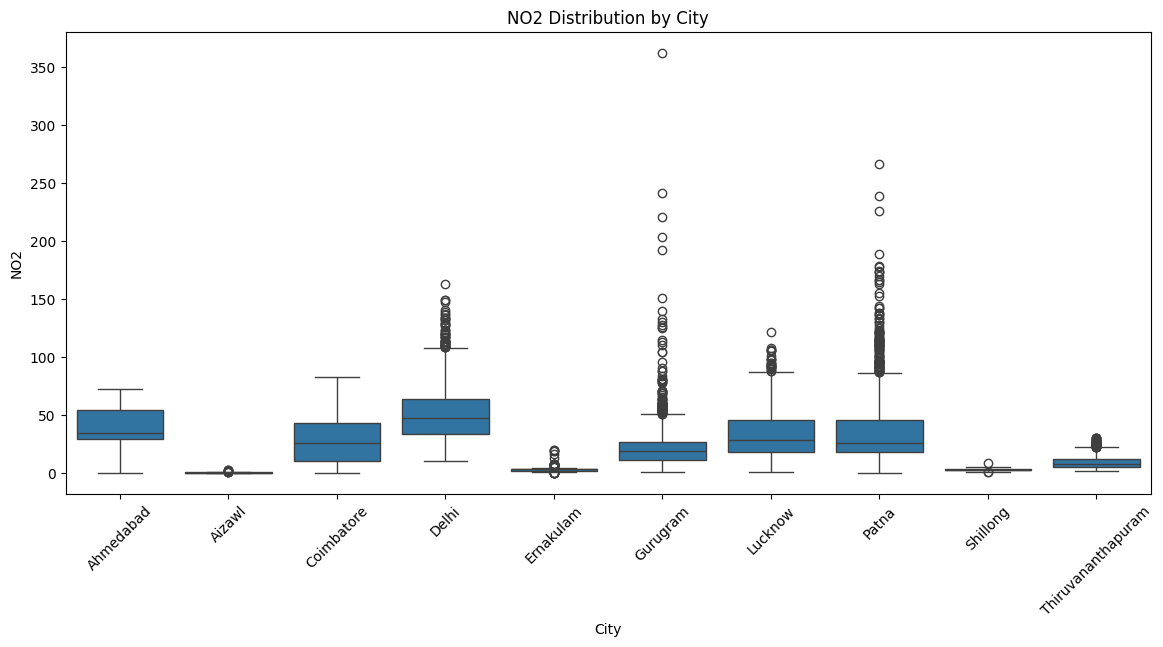

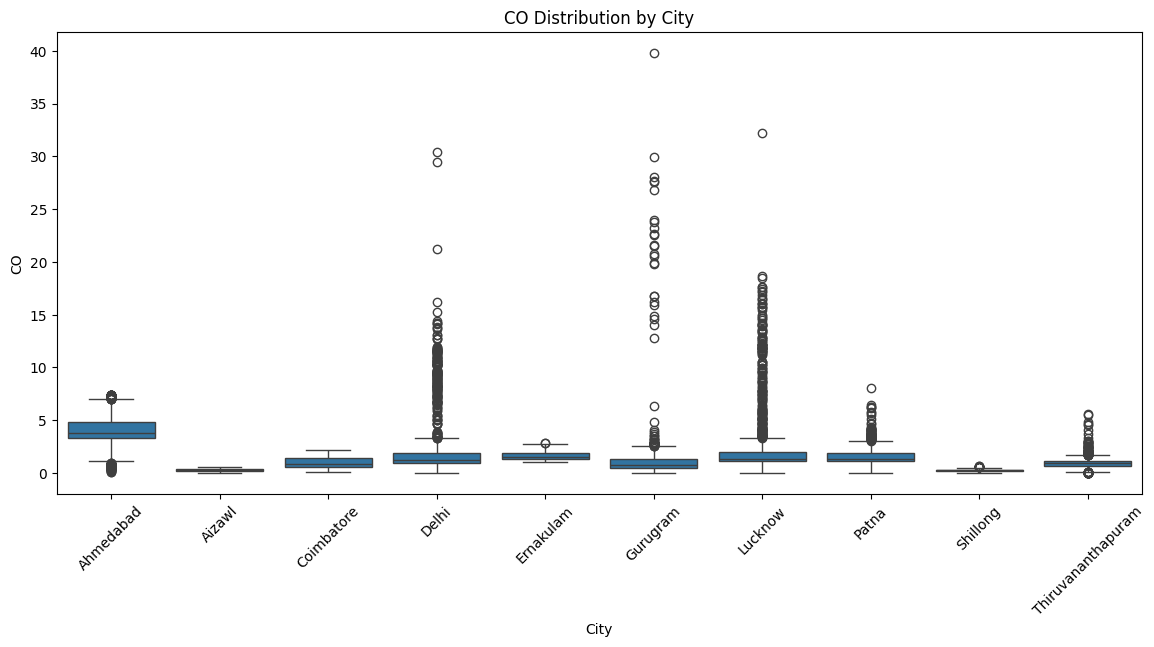

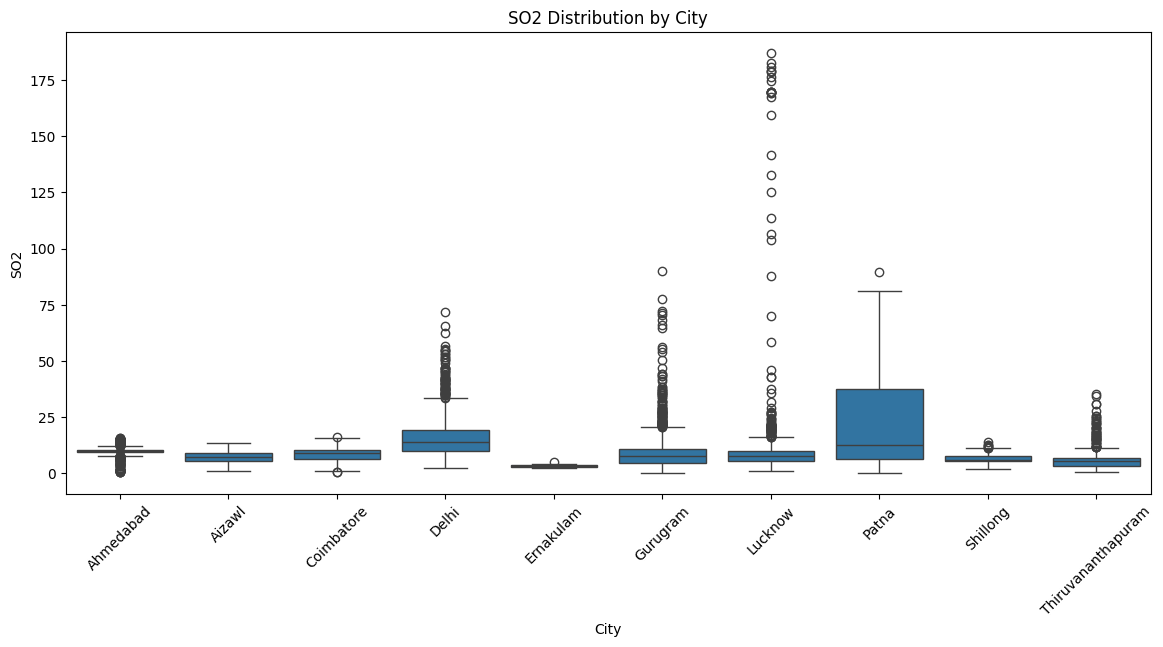

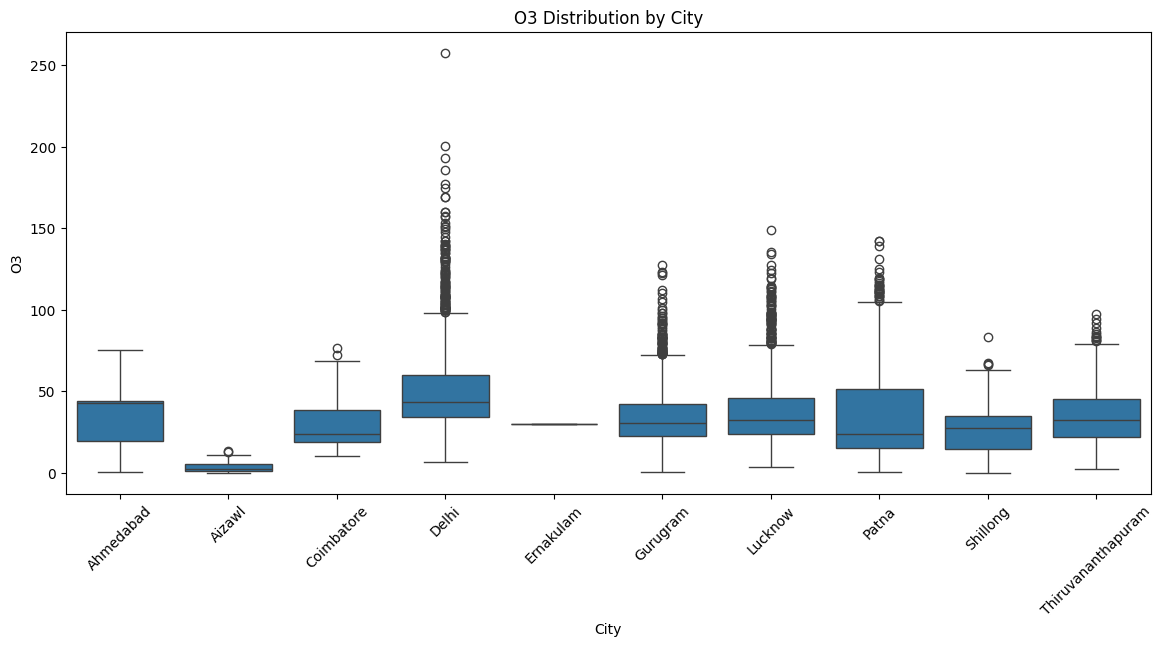

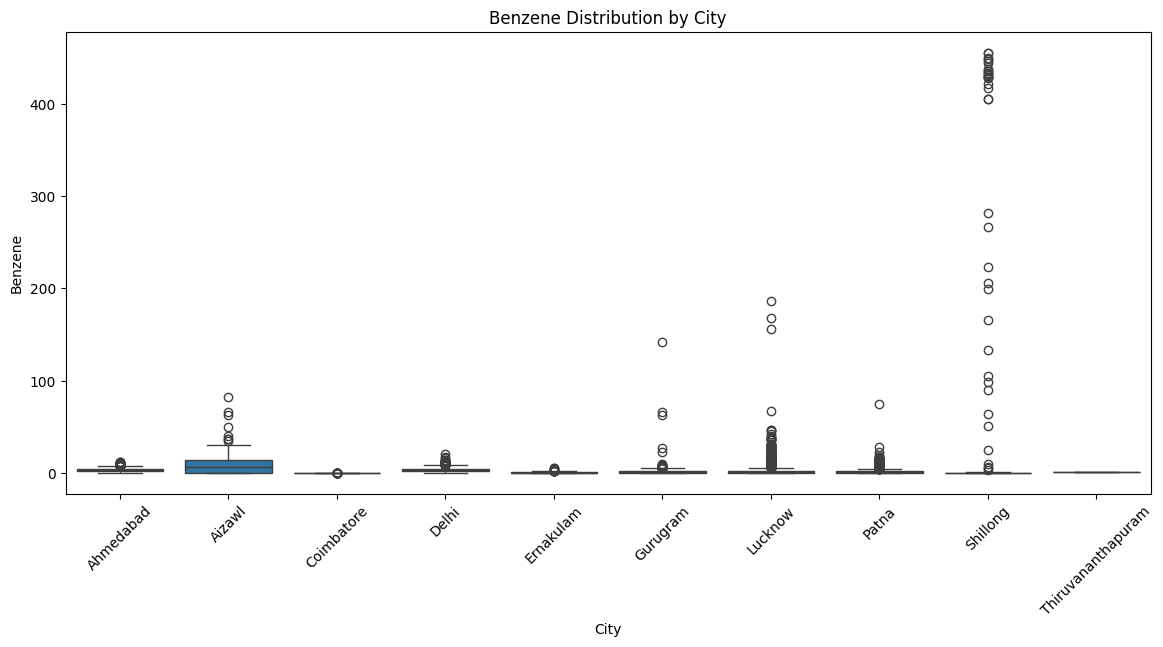

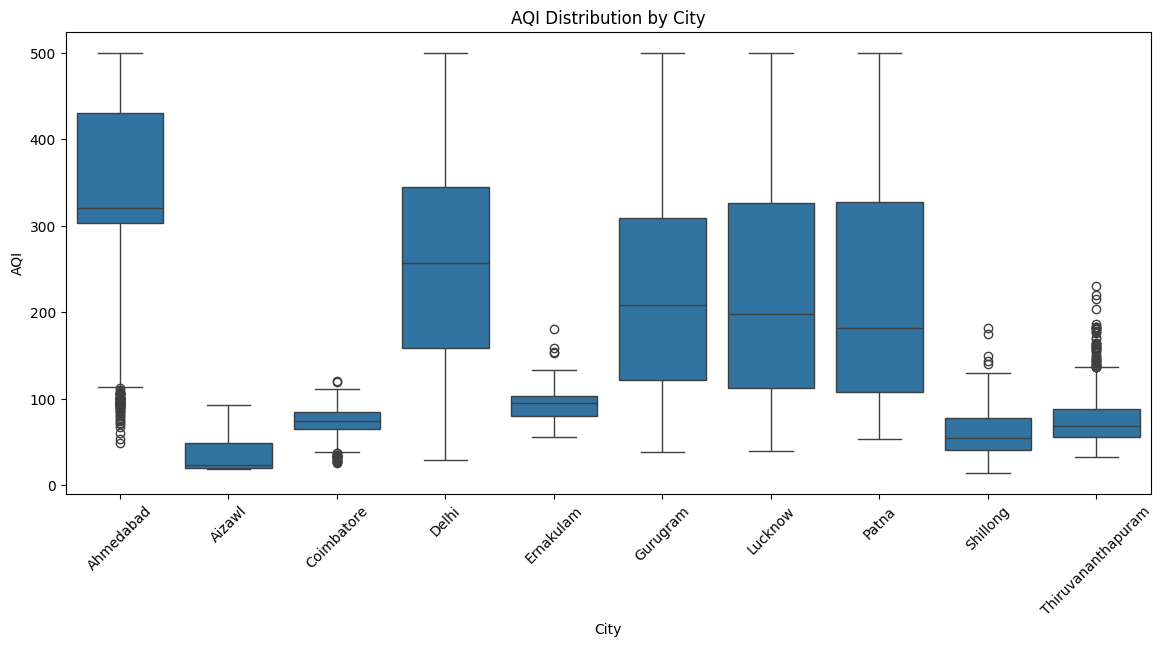

In [44]:
box_data = df[df['City'].isin(selected)]

for pol in pollutants:
    plt.figure(figsize=(14,6))
    sns.boxplot(data=box_data,x='City',y=pol)
    plt.title(f'{pol} Distribution by City')
    plt.xticks(rotation=45)
    plt.show()
    

## 4.6 AQI Bucket Distribution — Pie Chart

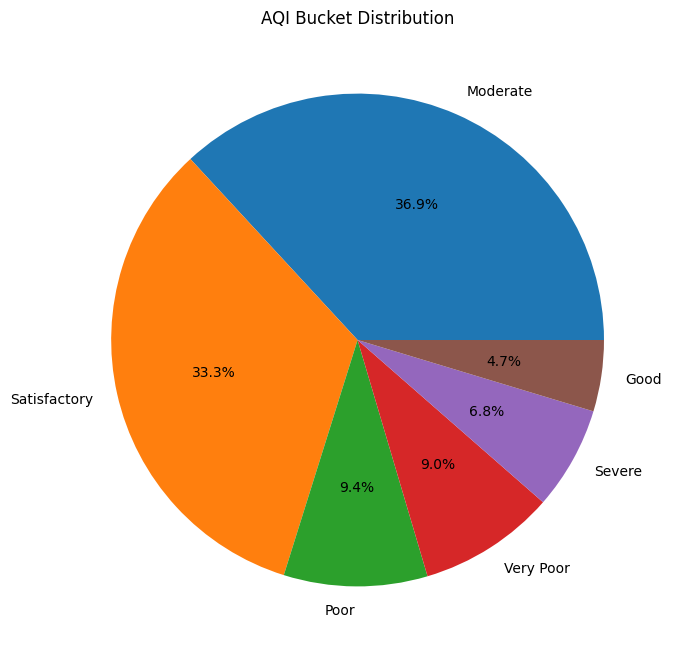

In [45]:
bucket_counts = df['AQI_Bucket'].value_counts()
plt.figure(figsize=(8,8))
plt.pie(bucket_counts.values,labels=bucket_counts.index,autopct='%1.1f%%')
plt.title('AQI Bucket Distribution')
plt.show()    

## 4.7 Scatter Plots — PM2.5 vs AQI & CO vs Year

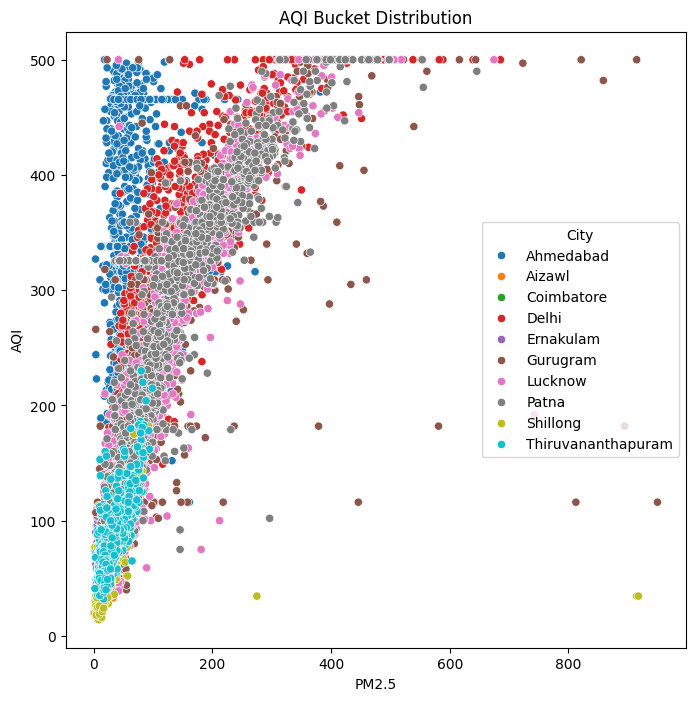

In [46]:
plt.figure(figsize=(8,8))
sns.scatterplot(box_data,x='PM2.5',y='AQI',hue='City')
plt.title('AQI Bucket Distribution')
plt.show()    

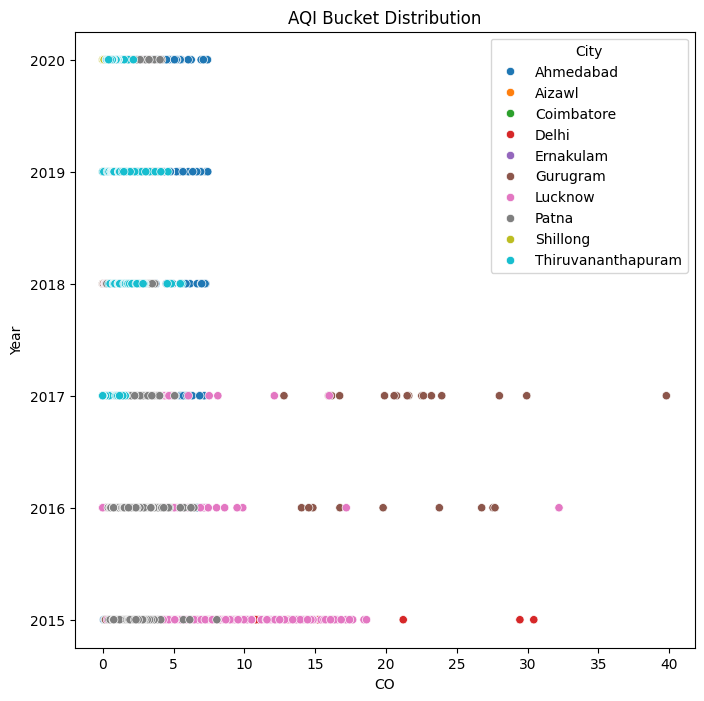

In [47]:
plt.figure(figsize=(8,8))
sns.scatterplot(box_data,x='CO',y='Year',hue='City')
plt.title('AQI Bucket Distribution')
plt.show()    